# Evaluación de Modelos de Aprendizaje No Supervisado

En este laboratorio vamos a evaluar un modelo de aprendizaje no supervisado, KNN, y su efectividad sobre un dataset sintético.

### SETUP

In [2]:
!pip install -q numpy
!pip install -q pandas
!pip install -q scikit-learn
!pip install -q matplotlib
!pip install -q scipy

In [3]:
#Importamos librerias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.datasets import make_classification
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from scipy.spatial import Voronoi, voronoi_plot_2d
from matplotlib.patches import Patch
from matplotlib import cm

#Creamos Dataset
X, Y = make_blobs(n_samples=500, n_features=2, centers=4, cluster_std=[1.0, 3, 5, 2], random_state=42)

Lógicamente en este caso no hay un estudio del dataset a realizar, sin embargo podemos aclarar que los "blobs" son creados con distintas desviaciones, en particular [1,2,3,5]. Esto nos permite estudiar su efectividad en distintos contextos.

# Creación de Modelo
Creemos el modelo KNN y apliquémoslo al Dataset

In [4]:
k_means = KMeans(n_clusters=4, random_state=42)
y_kmeans = k_means.fit_predict(X)

## Analisis de Resultados
Teniendo nuestro modelo entrenado podemos emplear algunas métricas para ver que tan estable es respecto a nuevos datasets. <br>En una primera instancia veamos la inercia de nuestros agrupamientos:

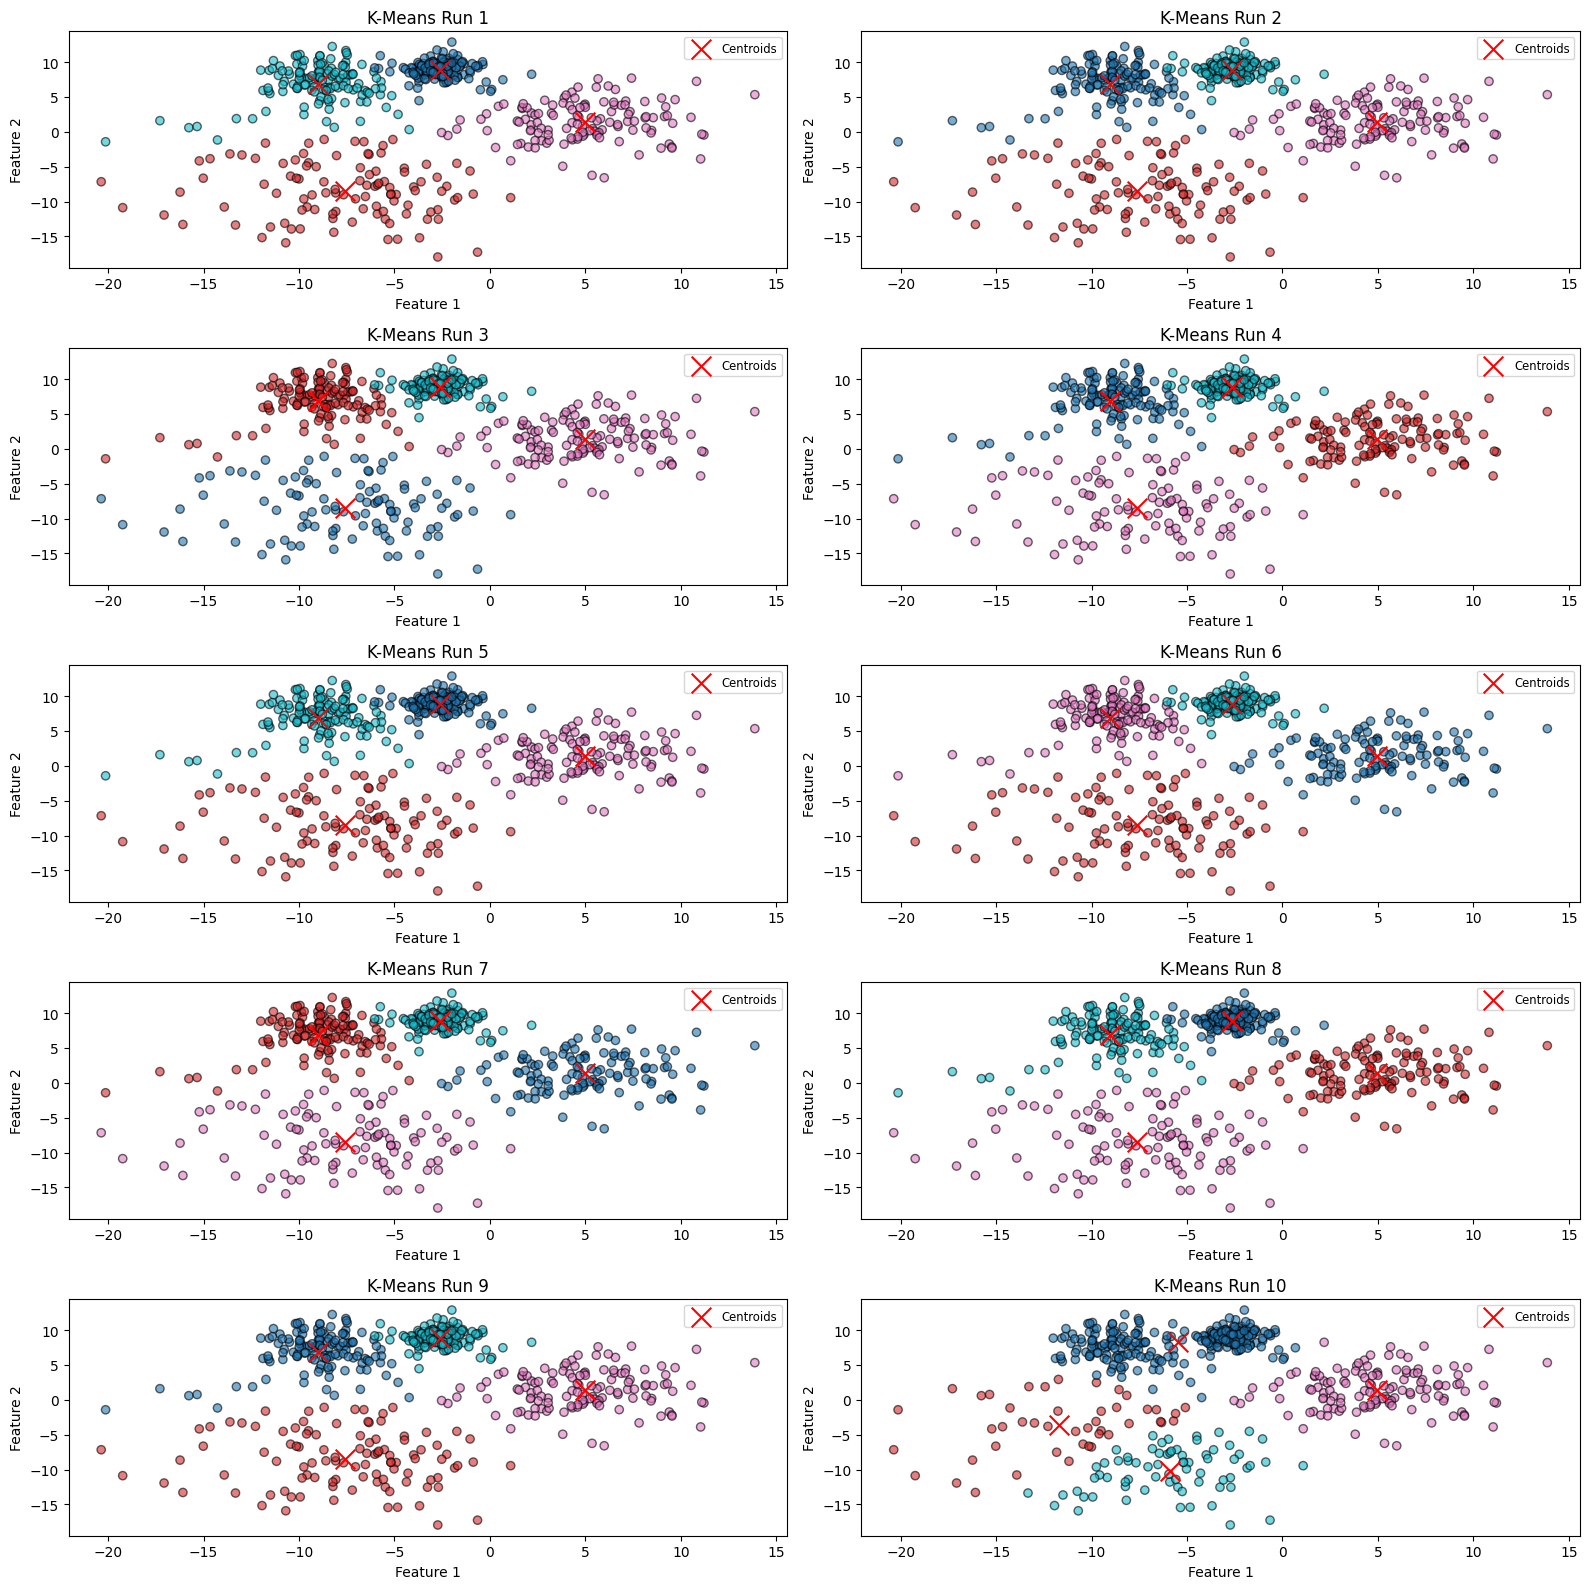

Run 1: Inertia=7633.68
Run 2: Inertia=7633.68
Run 3: Inertia=7633.51
Run 4: Inertia=7633.51
Run 5: Inertia=7633.51
Run 6: Inertia=7633.51
Run 7: Inertia=7633.51
Run 8: Inertia=7633.68
Run 9: Inertia=7633.68
Run 10: Inertia=8575.44


In [5]:
# Number of runs for k-means with different random states
n_runs = 10
inertia_values = []

# Calculate number of rows and columns needed for subplots
n_cols = 2 # Number of columns
n_rows = -(-n_runs // n_cols) # Ceil division to determine rows
plt.figure(figsize=(16, 16)) # Adjust the figure size for better visualization

# Run K-Means multiple times with different random states
for i in range(n_runs):
    kmeans = KMeans(n_clusters=4, random_state=None)  # Use the default `n_init`
    kmeans.fit(X)
    inertia_values.append(kmeans.inertia_)

    # Plot the clustering result
    plt.subplot(n_rows, n_cols, i + 1)
    plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='tab10', alpha=0.6, edgecolor='k')
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', s=200, marker='x', label='Centroids')
    plt.title(f'K-Means Run {i + 1}')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend(loc='upper right', fontsize='small')

plt.tight_layout()
plt.show()

# Print inertia values
for i, inertia in enumerate(inertia_values, start=1):
    print(f'Run {i}: Inertia={inertia:.2f}')

Recordemos que la inercia es en pocas palabras que tan agrupados los puntos estan respecto a su centro y que valores altos indican buen agrupamiento. Sin embargo a esta altura del analísis y dado que gran parte de los ciclos mantuvieron valores similares podemos concluir que tenemos un modelo bastante estable, en particular viendo como 5 _runs_ tienen valores identicos y 9 de 10 practicamente iguales. <br> Veamos ahora el indice Davies-Bouldin

In [6]:
print(davies_bouldin_score(X, y_kmeans))

0.5973646020406429


En general valores menores a 1 indican límites claros con poco overlapping. Por ultimo analicemos el _Silhouette Score_, recordemos que este nos va a indicar que tan denso es un cluster y su separación con otros.

In [7]:
print(silhouette_score(X, y_kmeans))

0.5298845291586521


Recordemos que su rango oscila entre -1 y 1, por lo tanto si bien no es un valor altísimo es considerado suficientemente bueno tener un valor de 0.5, gracias a esto podemos concluir que tiene una buena concentración y división en los clusters. Esto es deducible a ojo viendo los gráficos mostrados anteriormente, donde varios clusters estan bien agrupados salvo por aquel ubicado en la esquina inferior izquierda.